In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [70]:
# load dataset
player_weekly = pd.read_csv('/content/drive/MyDrive/weekly_player_stats_offense.csv', delimiter=',')

In [71]:
player_weekly.shape

(76287, 678)

In [72]:
player_weekly.head()

,player_id,pfr_player_id,player_name,position,position_group,team,birth_date,height,weight,college_name,...,cum_first_down_rush,cum_third_down_converted,cum_third_down_failed,cum_fourth_down_converted,cum_fourth_down_failed,cum_safety,cum_tackled_for_loss,cum_fantasy_points_standard,cum_fantasy_points_half_ppr,cum_fantasy_points_ppr
0,00-0038389,AbanIs00,Israel Abanikanda,RB,RB,NYJ,2002-10-05,70.0,216.0,Pittsburgh,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.6,2.1,2.6
1,00-0038389,AbanIs00,Israel Abanikanda,RB,RB,NYJ,2002-10-05,70.0,216.0,Pittsburgh,...,1.0,0.0,1.0,0.0,0.0,0.0,2.0,1.5,2.0,2.5
2,00-0038389,AbanIs00,Israel Abanikanda,RB,RB,NYJ,2002-10-05,70.0,216.0,Pittsburgh,...,1.0,0.0,1.0,0.0,0.0,0.0,2.0,3.4,4.9,6.4
3,00-0038389,AbanIs00,Israel Abanikanda,RB,RB,NYJ,2002-10-05,70.0,216.0,Pittsburgh,...,3.0,0.0,1.0,0.0,0.0,0.0,2.0,7.7,9.2,10.7
4,00-0038389,AbanIs00,Israel Abanikanda,RB,RB,NYJ,2002-10-05,70.0,216.0,Pittsburgh,...,3.0,0.0,2.0,0.0,0.0,0.0,2.0,10.7,14.2,17.7


In [73]:
# isolate all features that say "fantasy" to only keep fantasy_points_standard as y
fantasy_features = []
for feature in player_weekly.columns:
  if "fantasy" in feature:
    fantasy_features.append(feature)

fantasy_features.remove('fantasy_points_standard')

In [74]:
# Drop all other fantasy information since fantasy_points_standard is main outcome variable
player_weekly = player_weekly.drop(fantasy_features, axis=1)

In [75]:
player_weekly.shape

(76287, 649)

In [76]:
# Remove unnecessary player info, since we can access players by id which is primary key
player_weekly = player_weekly.drop(['pfr_player_id'], axis=1)

In [77]:
player_weekly.shape

(76287, 648)

**Descriptive Analytics**

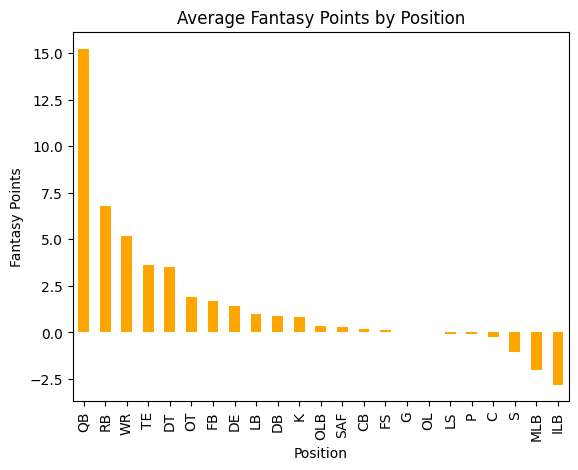

In [78]:
# Fantasy points grouped by position
position_points = player_weekly.groupby('position')['fantasy_points_standard'].mean()
position_points = position_points.sort_values(ascending=False)

position_points.plot(kind = 'bar', color = 'orange')
plt.title('Average Fantasy Points by Position')
plt.xlabel('Position')
plt.ylabel('Fantasy Points')
plt.show()

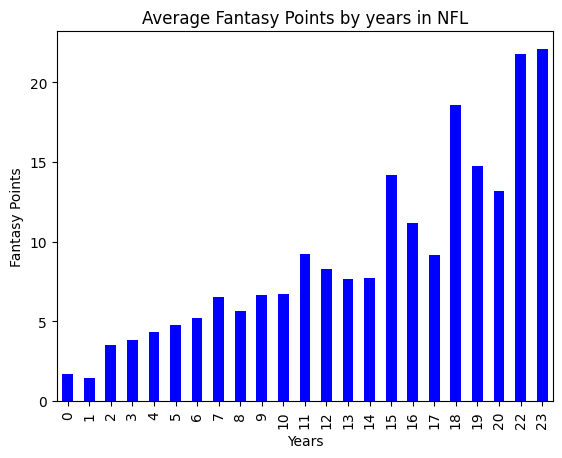

In [79]:
# Fantasy points grouped by experience in years
points_by_year = player_weekly.groupby('years_exp')['fantasy_points_standard'].mean()

points_by_year.plot(kind = 'bar', color = 'blue')
plt.title('Average Fantasy Points by years in NFL')
plt.xlabel('Years')
plt.ylabel('Fantasy Points')
plt.show()

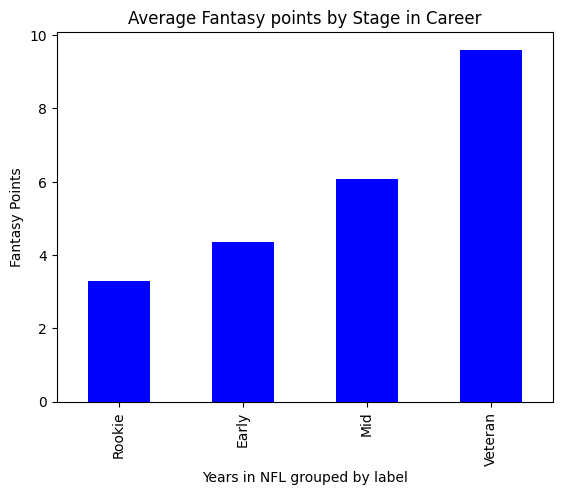

In [80]:
# Years experience put into bins
# Rookie: years 1-2
# Early: years 3-5
# Mid: years 6-10
# Veteran: years 11-20
bins = [0, 2, 5, 10, 20]
labels = ['Rookie', 'Early', 'Mid', 'Veteran']
player_weekly['exp_group'] = pd.cut(player_weekly['years_exp'], bins=bins, labels=labels)

exp_points = player_weekly.groupby('exp_group')['fantasy_points_standard'].mean()
exp_points.plot(kind = 'bar', color = 'blue')

plt.title('Average Fantasy points by Stage in Career')
plt.xlabel('Years in NFL grouped by label')
plt.ylabel('Fantasy Points')
plt.show()

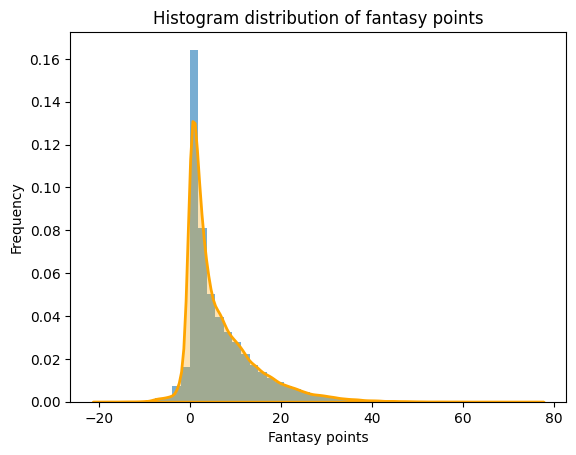

In [81]:
# Histogram distribution of fantasy points
import seaborn as sns
plt.hist(player_weekly['fantasy_points_standard'], bins = 50,  density = True, alpha = 0.6)
sns.kdeplot(player_weekly['fantasy_points_standard'], color='orange', linewidth=2, fill = True, alpha= 0.3)

plt.title('Histogram distribution of fantasy points')
plt.xlabel('Fantasy points')
plt.ylabel('Frequency')
plt.show()

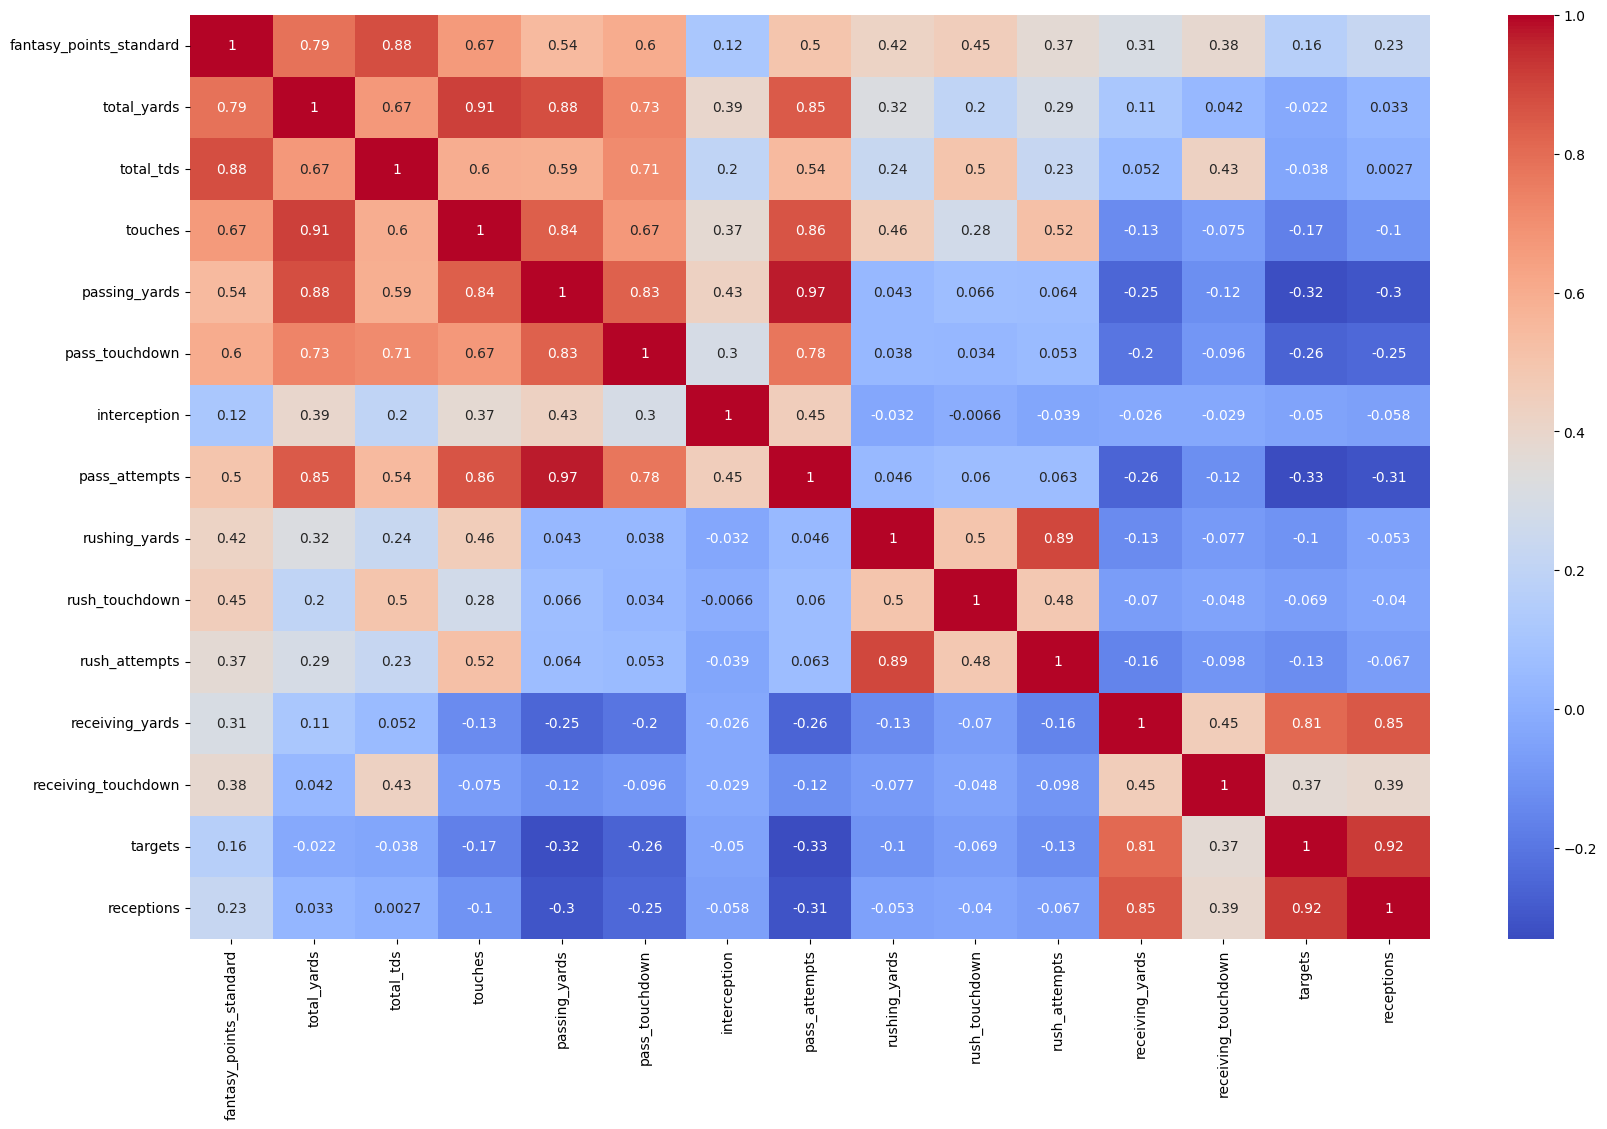

In [82]:
# Correlation heatmap
# Pick only columns I want to explore since doing a heatmap on everything would be too big and too computationally expensive

# Fantasy points are heavily correlated with yards and touchdowns, makes sense
cols = [
    'fantasy_points_standard',
    'total_yards',
    'total_tds',
    'touches',

    'passing_yards',
    'pass_touchdown',
    'interception',
    'pass_attempts',

    'rushing_yards',
    'rush_touchdown',
    'rush_attempts',

    'receiving_yards',
    'receiving_touchdown',
    'targets',
    'receptions'
]

corr = player_weekly[cols].corr(numeric_only= True)
plt.figure(figsize=(20, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

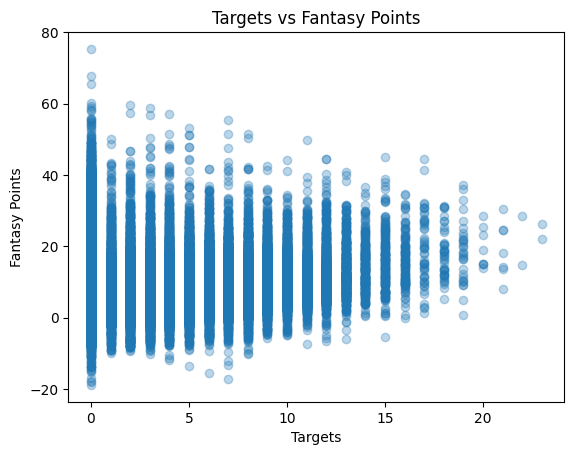

In [83]:
# Targets vs fantasy points
# Volume of targets doesn't gaurantee points, it averages out to a mean of around y = 20
plt.scatter(player_weekly['targets'], player_weekly['fantasy_points_standard'], alpha=0.3)
plt.xlabel('Targets')
plt.ylabel('Fantasy Points')
plt.title('Targets vs Fantasy Points')
plt.show()

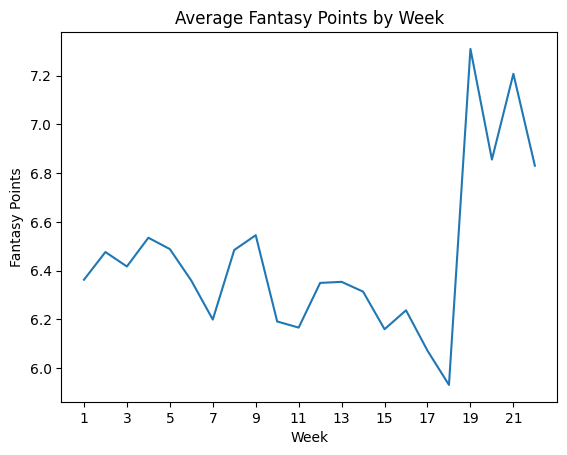

In [84]:
# Does fantasy points change by week?
# Points are relatively stable, games are much more competitive in week 18 and much less competitive in week 19
weekly_avg = player_weekly.groupby('week')['fantasy_points_standard'].mean()

weeks = weekly_avg.index
plt.xticks(np.arange(min(weeks), max(weeks) + 1, 2))
weekly_avg.plot()
plt.title('Average Fantasy Points by Week')
plt.xlabel('Week')
plt.ylabel('Fantasy Points')
plt.show()

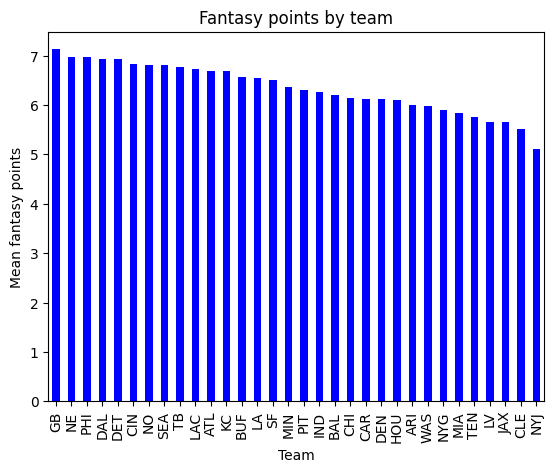

<Figure size 4000x1000 with 0 Axes>

In [85]:
# Does team make an impact?
team_means = player_weekly.groupby('team')['fantasy_points_standard'].mean().sort_values(ascending = False)
team_means.plot(kind = "bar", color = "blue")
plt.title('Fantasy points by team')
plt.xlabel('Team')
plt.ylabel('Mean fantasy points')
plt.figure(figsize=(40, 10))
plt.show()

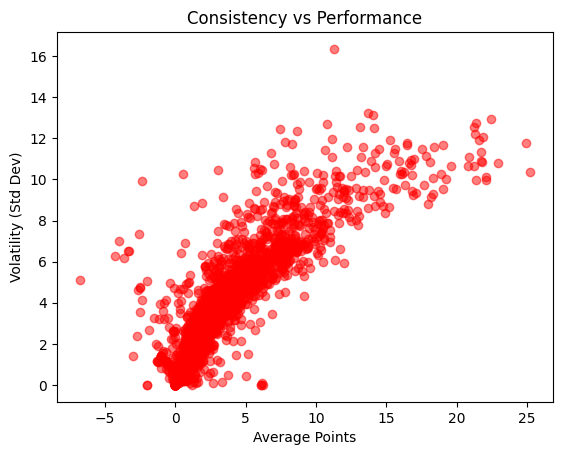

In [86]:
# Any volatility in fantasy points?
# there are a few outliers
player_stats = player_weekly.groupby('player_name')['fantasy_points_standard'].agg(['mean','std'])

plt.scatter(player_stats['mean'], player_stats['std'], alpha=0.5, color = "red")
plt.xlabel('Average Points')
plt.ylabel('Volatility (Std Dev)')
plt.title('Consistency vs Performance')
plt.show()



---

X and Y & Train-Test Split

In [87]:
# create rolling average column with cumulative rolling average
player_weekly = player_weekly.sort_values(['player_id', 'week'])

player_weekly['fp_rolling_avg'] = (
    player_weekly.groupby('player_id')['fantasy_points_standard']
    .transform(lambda x: x.shift(1).expanding().mean())
)

In [88]:
# define X and y
player_weekly = player_weekly.dropna(subset=['fp_rolling_avg'])

predictors = player_weekly.drop('fantasy_points_standard', axis=1)
numeric_predictors = predictors.select_dtypes(include=['number'])

X = numeric_predictors
y = player_weekly['fantasy_points_standard']

In [89]:
# define training and testing set
cutoff = player_weekly['week'].quantile(0.8)
X_train = X[player_weekly['week'] < cutoff]
X_test  = X[player_weekly['week'] >= cutoff]
y_train = y[player_weekly['week'] < cutoff]
y_test  = y[player_weekly['week'] >= cutoff]

In [90]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((55526, 636), (18055, 636), (55526,), (18055,))

In [91]:
# feature engineer to remove players who appear in testing set, but not in training set
# players who only appear much later in the season
player_means = player_weekly[player_weekly['week'] < cutoff].groupby('player_id')['fantasy_points_standard'].mean()
test_mask = player_weekly['week'] >= cutoff
known_players = player_weekly[test_mask]['player_id'].isin(player_means.index)

X_test = X_test[known_players.values]
y_test = y_test[known_players.values]



---


Baseline Model

In [105]:
from sklearn.metrics import root_mean_squared_error
model_df = player_weekly.copy()
base_cols = model_df.iloc[:, 0:15].select_dtypes(include=['number']).columns.tolist()
len(base_cols)
predictors = model_df.drop('fantasy_points_standard', axis=1)
rolling_cols = predictors.select_dtypes(include=['number']).drop(columns=base_cols)

bad = ["cum", "trend", "avg", "z_score"]
for col in rolling_cols.columns:
    for word in bad:
        if word in col:
            rolling_cols = rolling_cols.drop(columns=col)
            break
windows = [3, 5, 8]

for col in rolling_cols:
    for w in windows:
        model_df[f'{col}_rolling{w}'] = (
            model_df.groupby('player_id')[col]
            .transform(lambda x: x.shift(1).rolling(window=w, min_periods=1).mean())
        )
rolling_feature_cols = [
    col for col in model_df.columns
    if '_rolling3' in col or '_rolling5' in col or '_rolling8' in col
]
feature_cols = base_cols + rolling_feature_cols
model_df['target_next_week'] = (
    model_df.groupby('player_id')['fantasy_points_standard'].shift(-1)
)
model_df = model_df.dropna()
model_X = model_df[feature_cols].copy()
model_y = model_df['target_next_week'].copy()
latest_season = model_df['season'].max()
week_cutoff = 12

model_train_idx = (
    (model_df['season'] < latest_season) |
    ((model_df['season'] == latest_season) & (model_df['week'] < week_cutoff))
)

model_test_idx = (
    (model_df['season'] == latest_season) & (model_df['week'] >= week_cutoff)
)

X_train = model_X.loc[model_train_idx]
X_test = model_X.loc[model_test_idx]
y_train = model_y.loc[model_train_idx]
y_test = model_y.loc[model_test_idx]
rmse = root_mean_squared_error

player_means = (
    model_df[model_train_idx]
    .groupby('player_id')['fantasy_points_standard']
    .mean()
)

test_players = model_df[model_test_idx]['player_id']
known_mask = test_players.isin(player_means.index)

X_test = X_test[known_mask.values]
y_test = y_test[known_mask.values]

baseline_pred = (
    model_df.groupby('player_id')['fantasy_points_standard']
    .transform(lambda x: x.shift(1).expanding().mean())
)

baseline_train_preds = baseline_pred[model_train_idx]
baseline_test_preds  = baseline_pred[model_test_idx].loc[known_mask[known_mask].index]

train_valid = baseline_train_preds.notna()
test_valid  = baseline_test_preds.notna()

X_train = X_train[train_valid]
y_train = y_train[train_valid]
X_test = X_test[test_valid]
y_test = y_test[test_valid]

baseline_train_preds = baseline_train_preds[train_valid]
baseline_test_preds = baseline_test_preds[test_valid]

print(f'Baseline RMSE (train): {rmse(y_train, baseline_train_preds):.4f}')
print(f'Baseline RMSE (test):  {rmse(y_test, baseline_test_preds):.4f}')

Baseline RMSE (train): 7.0062
Baseline RMSE (test):  6.4693


Text(0, 0.5, 'Actual')

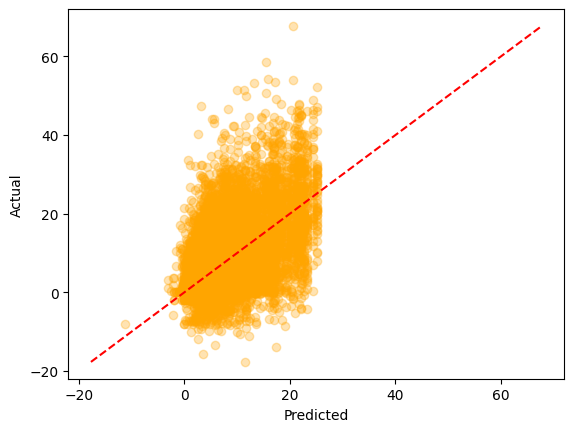

In [93]:
# visualize baseline model against observed data
plt.scatter(x = baseline_test, y = y_test, alpha=0.3, c='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Predicted')
plt.ylabel('Actual')



---



In [94]:
# =========================
# Modeling: weekly fantasy points prediction
# Goal: use prior weeks (rolling) to predict next week
# Includes: feature engineering + grouped K-fold CV + scaling/robust transforms
# =========================

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer, RobustScaler
from sklearn.impute import SimpleImputer
df = player_weekly.copy()
# Strip whitespace from column names to prevent KeyError due to hidden characters
df.columns = df.columns.str.strip()

# --- Feature engineering ---
# Efficiency ratios
if "total_yards" in df.columns and "touches" in df.columns:
  df["yards_per_touch"] = df["total_yards"] / df["touches"].replace(0, np.nan)
if "total_tds" in df.columns and "touches" in df.columns:
  df["tds_per_touch"] = df["total_tds"] / df["touches"].replace(0, np.nan)
if "receptions" in df.columns and "targets" in df.columns:
  df["catch_rate"] = df["receptions"] / df["targets"].replace(0, np.nan)
if "receiving_yards" in df.columns and "targets" in df.columns:
  df["yards_per_target"] = df["receiving_yards"] / df["targets"].replace(0, np.nan)

# Rolling features: use week 1+2 to predict week 3 (rolling mean of prior 2 weeks)
rolling_base_cols = [
  "touches",
  "total_yards",
  "total_tds",
  "targets",
  "receptions",
  "receiving_yards",
  "rushing_yards",
  "passing_yards",
]
rolling_cols = [c for c in rolling_base_cols if c in df.columns]

if ("player_name" in df.columns) and ("season" in df.columns) and ("week" in df.columns):
  df = df.sort_values(["player_name", "season", "week"])
  for c in rolling_cols:
    df[f"{c}_roll2"] = (
      df.groupby(["player_name", "season"], sort=False)[c]\
        .transform(lambda s: s.shift(1).rolling(window=2, min_periods=1).mean())
    )

  # Lagged prior-week fantasy points (very predictive, still leakage-safe because shifted)
  if "fantasy_points_standard" in df.columns:
    df["fp_lag1"] = (
      df.groupby(["player_name", "season"], sort=False)["fantasy_points_standard"]\
        .transform(lambda s: s.shift(1))
    )
    df["fp_roll2"] = (
      df.groupby(["player_name", "season"], sort=False)["fantasy_points_standard"]\
        .transform(lambda s: s.shift(1).rolling(window=2, min_periods=1).mean())
    )

Ridge

In [95]:
# Ridge
import pandas as pd
import numpy as np

# Reload original dataset so teammate cells do not affect this section
adi_df = pd.read_csv('/content/drive/MyDrive/weekly_player_stats_offense.csv')

# Basic cleaning, same idea as earlier notebook
adi_df = adi_df.dropna()

# Strip whitespace from column names
adi_df.columns = adi_df.columns.str.strip()

# Find player identifier column
player_id_col = None
for col in ['player_name', 'player_id', 'pfr_player_id']:
    if col in adi_df.columns:
        player_id_col = col
        break

if player_id_col is None:
    raise KeyError("No player identifier column found. Check your dataset columns.")

print("Using player identifier:", player_id_col)

# Sort by player and time
adi_df = adi_df.sort_values([player_id_col, 'season', 'week'])

# Create next-week target
adi_df['target_next_week'] = (
    adi_df.groupby(player_id_col)['fantasy_points_standard'].shift(-1)
)

# Drop rows where next-week target is unavailable
adi_df = adi_df.dropna(subset=['target_next_week'])

# Rolling feature columns
rolling_cols = [
    'fantasy_points_standard',
    'total_yards',
    'total_tds',
    'touches',
    'passing_yards',
    'pass_touchdown',
    'interception',
    'pass_attempts',
    'rushing_yards',
    'rush_touchdown',
    'receiving_yards',
    'receiving_touchdown',
    'targets',
    'receptions'
]

# Keep only columns that actually exist
rolling_cols = [col for col in rolling_cols if col in adi_df.columns]

# Create 3, 5, and 8 week rolling averages using only past weeks
windows = [3, 5, 8]

for col in rolling_cols:
    for w in windows:
        adi_df[f'{col}_rolling{w}'] = (
            adi_df.groupby(player_id_col)[col]
            .transform(lambda x: x.shift(1).rolling(window=w, min_periods=1).mean())
        )

# Base feature columns
base_features = [
    'years_exp',
    'week',
    'season',
    'position',
    'team',
    'exp_group'
]

# Keep only existing base features
base_features = [col for col in base_features if col in adi_df.columns]

# Use all rolling features created above
rolling_feature_cols = [
    col for col in adi_df.columns
    if '_rolling3' in col or '_rolling5' in col or '_rolling8' in col
]

adi_feature_cols = base_features + rolling_feature_cols

# Build X and y
adi_X = adi_df[adi_feature_cols].copy()
adi_y = adi_df['target_next_week'].copy()

# One-hot encode categorical variables
adi_X = pd.get_dummies(adi_X, drop_first=True)

# Time-based split:
# Train on all previous seasons + early weeks of latest season
# Test on later weeks of latest season
latest_season = adi_df['season'].max()
week_cutoff = 12

adi_train_idx = (
    (adi_df['season'] < latest_season) |
    ((adi_df['season'] == latest_season) & (adi_df['week'] < week_cutoff))
)

adi_test_idx = (
    (adi_df['season'] == latest_season) & (adi_df['week'] >= week_cutoff)
)

adi_X_train = adi_X.loc[adi_train_idx]
adi_X_test = adi_X.loc[adi_test_idx]
adi_y_train = adi_y.loc[adi_train_idx]
adi_y_test = adi_y.loc[adi_test_idx]

print("Data shape:", adi_df.shape)
print("X shape:", adi_X.shape)
print("y shape:", adi_y.shape)
print("Latest season:", latest_season)
print("Train weeks in latest season:", sorted(adi_df.loc[adi_train_idx & (adi_df['season'] == latest_season), 'week'].unique()))
print("Test weeks in latest season:", sorted(adi_df.loc[adi_test_idx, 'week'].unique()))
print("Train size:", adi_X_train.shape, adi_y_train.shape)
print("Test size:", adi_X_test.shape, adi_y_test.shape)

Using player identifier: player_name
Data shape: (47557, 721)
X shape: (47557, 94)
y shape: (47557,)
Latest season: 2025
Train weeks in latest season: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
Test weeks in latest season: [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]
Train size: (45984, 94) (45984,)
Test size: (1573, 94) (1573,)


In [96]:
#ridge reg
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

ridge_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

ridge_params = {
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=5,
    scoring='neg_mean_squared_error',
    error_score='raise'
)

ridge_grid.fit(adi_X_train, adi_y_train)

ridge_best = ridge_grid.best_estimator_
ridge_preds = ridge_best.predict(adi_X_test)

ridge_rmse = np.sqrt(mean_squared_error(adi_y_test, ridge_preds))
ridge_mae = mean_absolute_error(adi_y_test, ridge_preds)
ridge_r2 = r2_score(adi_y_test, ridge_preds)

print("Best Ridge alpha:", ridge_grid.best_params_)
print("Ridge RMSE:", ridge_rmse)
print("Ridge MAE:", ridge_mae)
print("Ridge R^2:", ridge_r2)

Best Ridge alpha: {'ridge__alpha': 10}
Ridge RMSE: 6.7192280542877505
Ridge MAE: 4.672513594918968
Ridge R^2: 0.34880565022928534


Best Ridge alpha: {'ridge__alpha': np.float64(18.73817422860383)}
Ridge RMSE: 6.719377911746205
Ridge MAE: 4.6724966835984105
Ridge R^2: 0.34877660301801294


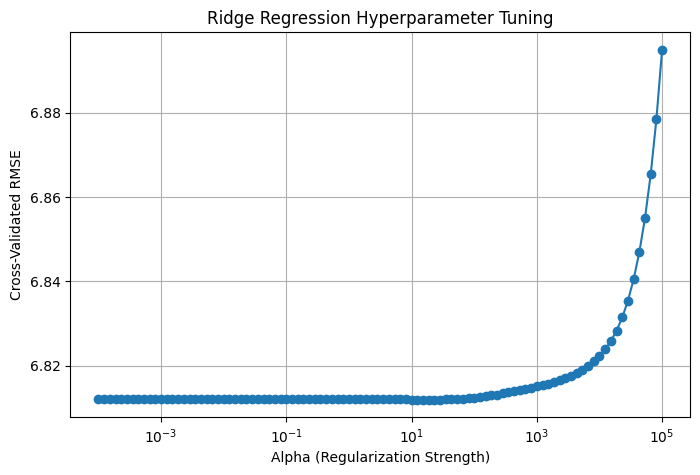

In [97]:
# Tuning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Pipeline
ridge_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Wide alpha grid (log scale)
ridge_params = {
    'ridge__alpha': np.logspace(-4, 5, 100)
}

# Grid search with CV
ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fit model
ridge_grid.fit(adi_X_train, adi_y_train)

# Best model + predictions
ridge_best = ridge_grid.best_estimator_
ridge_preds = ridge_best.predict(adi_X_test)

# Metrics
ridge_rmse = np.sqrt(mean_squared_error(adi_y_test, ridge_preds))
ridge_mae = mean_absolute_error(adi_y_test, ridge_preds)
ridge_r2 = r2_score(adi_y_test, ridge_preds)

print("Best Ridge alpha:", ridge_grid.best_params_)
print("Ridge RMSE:", ridge_rmse)
print("Ridge MAE:", ridge_mae)
print("Ridge R^2:", ridge_r2)

# ==============================
# Plot: Alpha vs RMSE (for presentation)
# ==============================

ridge_results = pd.DataFrame(ridge_grid.cv_results_)
ridge_results['RMSE'] = np.sqrt(-ridge_results['mean_test_score'])

plt.figure(figsize=(8,5))
plt.plot(ridge_results['param_ridge__alpha'], ridge_results['RMSE'], marker='o')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Cross-Validated RMSE')
plt.title('Ridge Regression Hyperparameter Tuning')
plt.grid(True)
plt.show()



---

Lasso Model

In [98]:
# finding best alpha for lasso model
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas=np.logspace(-4, 2, 50), cv=5)
lasso_cv.fit(X_train, y_train)
best_alpha = lasso_cv.alpha_

In [99]:
print("Best alpha:", lasso_cv.alpha_)

Best alpha: 0.012067926406393288


In [100]:
# @title
# # lasso with best alpha, comparing to previous model
# lasso_best_a = Lasso(alpha = model.alpha_)
# lasso_pipe_best_a = make_pipeline(scaler, lasso_best_a)
# lasso_pipe_best_a.fit(X_train, y_train)

# print(f'RMSE on X_train (alpha = 1): {rmse(lasso_pipe_a1.predict(X_train), y_train)}')
# print(f'RMSE on X_test (alpha = 1): {rmse(lasso_pipe_a1.predict(X_test), y_test)}\n')
# print(f'RMSE on X_train (alpha = {model.alpha_:0.4f}): {rmse(lasso_pipe_best_a.predict(X_train), y_train)}')
# print(f'RMSE on X_test (alpha = {model.alpha_:0.4f}): {rmse(lasso_pipe_best_a.predict(X_test), y_test)}')

In [101]:
# @title
# # select best predictors from dataset
# from sklearn.feature_selection import SelectFromModel
# from sklearn.linear_model import Lasso

# lasso = Lasso(alpha = model.alpha_)
# selector = SelectFromModel(lasso, prefit=False)
# X_reduced = selector.fit_transform(X_train, y_train)

In [106]:
# lasso with best predictors/alpha
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline

rmse = root_mean_squared_error

scaler = StandardScaler()
lasso_pipe = make_pipeline(scaler, SelectFromModel(Lasso(alpha=best_alpha)), Lasso(alpha=best_alpha))
lasso_pipe.fit(X_train, y_train)
y_pred = lasso_pipe.predict(X_test)

print(f'RMSE on X_train with best predictors (alpha = {best_alpha:0.4f}): {rmse(lasso_pipe.predict(X_train), y_train)}')
print(f'RMSE on X_test with best predictors (alpha = {best_alpha:0.4f}): {rmse(y_pred, y_test)}')
print(f'RMSE of baseline model: {rmse(baseline_test_preds, y_test)}')

RMSE on X_train with best predictors (alpha = 0.0121): 6.932166969572822
RMSE on X_test with best predictors (alpha = 0.0121): 6.540980536433778
RMSE of baseline model: 6.469324785745479


In [107]:
 # absolute difference in RMSE from baseline to lasso model

diff = np.abs(rmse(baseline_test_preds, y_test) - rmse(y_pred, y_test))
print(f'Absolute difference in RMSE from baseline model to fitted lasso model:', diff)

Absolute difference in RMSE from baseline model to fitted lasso model: 0.07165575068829888


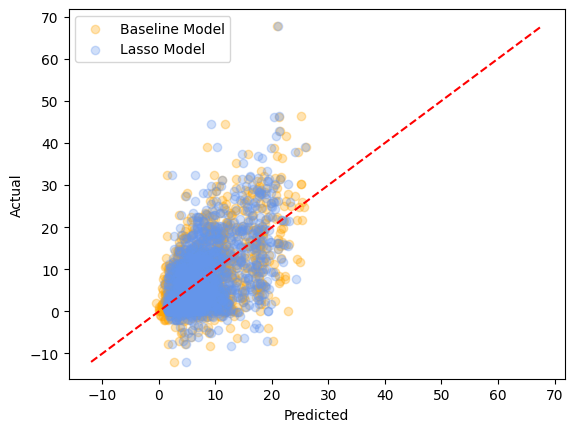

In [108]:
# visualize results
plt.scatter(x = baseline_test_preds, y = y_test, alpha=0.3, c='orange', label='Baseline Model')
plt.scatter(x = y_pred, y = y_test, alpha=0.3, c='cornflowerblue', label='Lasso Model')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.legend()

In [109]:
selector = lasso_pipe.named_steps['selectfrommodel']
mask = selector.get_support()

feature_names = np.array(X_train.columns)[mask]
coefficients = selector.estimator_.coef_[mask]

importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', key=abs, ascending=False)

print(importance_df[0:5])

                   feature  coefficient
76    total_yards_rolling8     1.344158
50  rush_attempts_rolling8     1.098107
66    offense_pct_rolling8     0.888127
75        touches_rolling8     0.749674
78      total_tds_rolling8     0.529226


In [110]:
len(feature_names)

80

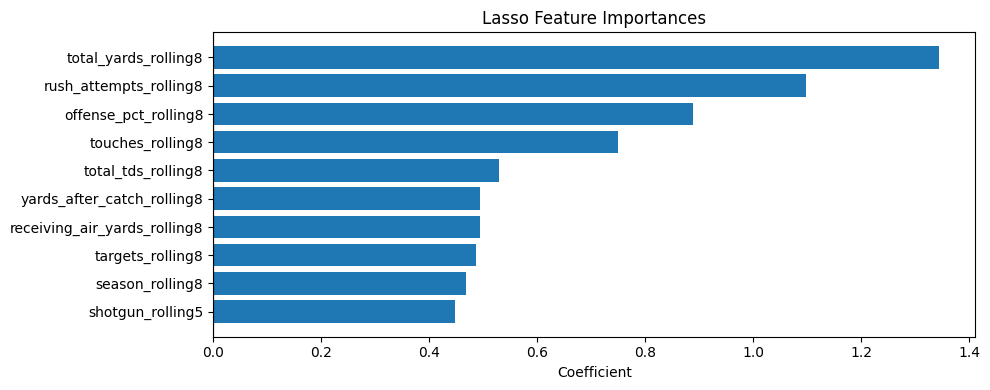

In [111]:
importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', key=abs, ascending=False).head(10)

plt.figure(figsize=(10, len(importance_df) * 0.4))
plt.barh(importance_df['feature'], importance_df['coefficient'])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient')
plt.title('Lasso Feature Importances')
plt.gca().invert_yaxis()  # most important at top
plt.tight_layout()
plt.show()

In [112]:
selected = lasso_pipe[1].get_support()
feature_names = X_train.columns[selected]
coefs = lasso_pipe[2].coef_
print(sorted(zip(feature_names, coefs), key=lambda x: abs(x[1]), reverse=True)[:10])

[('total_yards_rolling8', np.float64(1.3494825956208982)), ('rush_attempts_rolling8', np.float64(1.17873002943704)), ('offense_pct_rolling8', np.float64(0.8928292205256113)), ('touches_rolling8', np.float64(0.5608896453253491)), ('total_tds_rolling8', np.float64(0.524127411395908)), ('yards_after_catch_rolling8', np.float64(0.5237937484131883)), ('receiving_air_yards_rolling8', np.float64(0.49653887273048936)), ('targets_rolling8', np.float64(0.4901233146122296)), ('season_rolling8', np.float64(0.4644414759727376)), ('offense_snaps_rolling3', np.float64(-0.44106704676313374))]


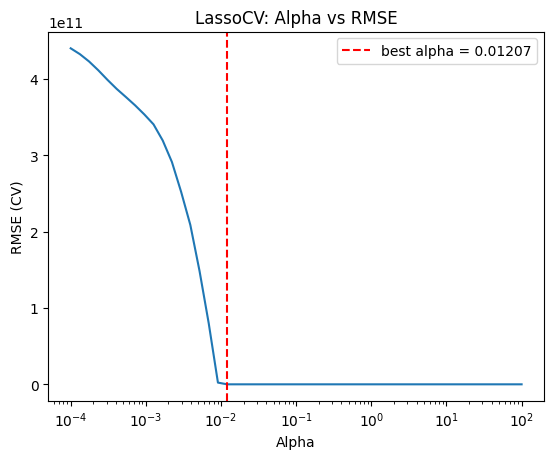

In [113]:
rmse_path = np.sqrt(lasso_cv.mse_path_.mean(axis=1))

plt.plot(lasso_cv.alphas_, rmse_path)
plt.axvline(lasso_cv.alpha_, linestyle='--', color='red', label=f'best alpha = {lasso_cv.alpha_:.5f}')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('RMSE (CV)')
plt.title('LassoCV: Alpha vs RMSE')
plt.legend()
plt.show()

In [114]:
positions = ['QB', 'RB', 'WR', 'TE']
results = {}

for pos in positions:
    pos_mask = model_df['position'] == pos
    pos_data = model_df[pos_mask]

    X_pos = model_X[pos_mask]
    y_pos = model_y[pos_mask]

    train_idx_pos = model_train_idx[pos_mask]
    test_idx_pos  = model_test_idx[pos_mask]

    X_train_pos = X_pos[train_idx_pos]
    X_test_pos  = X_pos[test_idx_pos]
    y_train_pos = y_pos[train_idx_pos]
    y_test_pos  = y_pos[test_idx_pos]

    known_mask_pos = pos_data[test_idx_pos]['player_id'].isin(
        pos_data[train_idx_pos].groupby('player_id')['fantasy_points_standard'].mean().index
    )

    X_test_pos = X_test_pos.loc[known_mask_pos[known_mask_pos].index]
    y_test_pos = y_test_pos.loc[known_mask_pos[known_mask_pos].index]

    baseline_pred_pos = (
        pos_data.groupby('player_id')['fantasy_points_standard']
        .transform(lambda x: x.shift(1).expanding().mean())
    )
    baseline_train_pos = baseline_pred_pos[train_idx_pos]
    baseline_test_pos  = baseline_pred_pos[test_idx_pos].loc[known_mask_pos[known_mask_pos].index]

    train_valid_pos = baseline_train_pos.notna()
    test_valid_pos  = baseline_test_pos.notna()

    lasso_cv_pos = LassoCV(alphas=np.logspace(-4, 2, 50), cv=5)
    lasso_cv_pos.fit(X_train_pos, y_train_pos)

    lasso_pipe_pos = make_pipeline(
        StandardScaler(),
        SelectFromModel(Lasso(alpha=lasso_cv_pos.alpha_)),
        Lasso(alpha=lasso_cv_pos.alpha_)
    )
    lasso_pipe_pos.fit(X_train_pos, y_train_pos)

    results[pos] = {
        'lasso_train_rmse':    rmse(y_train_pos[train_valid_pos], lasso_pipe_pos.predict(X_train_pos[train_valid_pos])),
        'lasso_test_rmse':     rmse(y_test_pos[test_valid_pos],   lasso_pipe_pos.predict(X_test_pos[test_valid_pos])),
        'baseline_train_rmse': rmse(y_train_pos[train_valid_pos], baseline_train_pos[train_valid_pos]),
        'baseline_test_rmse':  rmse(y_test_pos[test_valid_pos],   baseline_test_pos[test_valid_pos]),
        'alpha': lasso_cv_pos.alpha_
    }

In [115]:
for pos, res in results.items():
    print(f"{pos}: Lasso=({res['lasso_train_rmse']:.4f}, {res['lasso_test_rmse']:.4f}), Baseline=({res['baseline_train_rmse']:.4f}, {res['baseline_test_rmse']:.4f}), alpha={res['alpha']:.4f}")

QB: Lasso=(10.8005, 10.6706), Baseline=(10.8299, 10.3914), alpha=0.2683
RB: Lasso=(7.3114, 6.7053), Baseline=(7.3673, 6.8249), alpha=0.6251
WR: Lasso=(5.9030, 5.7906), Baseline=(5.9650, 5.6990), alpha=0.1151
TE: Lasso=(4.6213, 4.0923), Baseline=(4.5097, 4.1532), alpha=1.0985


Bagging

In [117]:
# Bagging

from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

bagging_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('bagging', BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        random_state=42,
        n_jobs=-1
    ))
])

bagging_params = {
    'bagging__n_estimators': [100],
    'bagging__max_samples': [0.8],
    'bagging__estimator__max_depth': [5, 10],
    'bagging__estimator__min_samples_leaf': [3, 5]
}

bagging_grid = GridSearchCV(
    bagging_pipeline,
    bagging_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

bagging_grid.fit(X_train, y_train)

bagging_best = bagging_grid.best_estimator_
bagging_preds = bagging_best.predict(X_test)

bagging_rmse = np.sqrt(mean_squared_error(y_test, bagging_preds))
bagging_mae = mean_absolute_error(y_test, bagging_preds)
bagging_r2 = r2_score(y_test, bagging_preds)

print("Best Bagging params:", bagging_grid.best_params_)
print("Bagging RMSE:", bagging_rmse)
print("Bagging MAE:", bagging_mae)
print("Bagging R^2:", bagging_r2)

#predict on x train and x test
train_preds = bagging_best.predict(X_train)
test_preds  = bagging_best.predict(X_test)

#calc rmse
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
test_rmse  = np.sqrt(mean_squared_error(y_test, test_preds))

print("Bagging Train RMSE:", round(train_rmse, 4))
print("Bagging Test RMSE:", round(test_rmse, 4))

Best Bagging params: {'bagging__estimator__max_depth': 5, 'bagging__estimator__min_samples_leaf': 5, 'bagging__max_samples': 0.8, 'bagging__n_estimators': 100}
Bagging RMSE: 6.582119712015478
Bagging MAE: 4.8781155022743015
Bagging R^2: 0.3209406882603342
Bagging Train RMSE: 6.8779
Bagging Test RMSE: 6.5821


Random Forest


In [118]:
# Random forest preprocessing

# imports
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# establish target and vectorize position
TARGET = 'fantasy_points_standard'
le = LabelEncoder()
player_weekly['position_enc'] = le.fit_transform(player_weekly['position'].astype(str))

In [119]:
# Pipeline to evaluate random forest on all possibly important metrics
def evaluate(name, model, X_train, X_test, y_train, y_test, features):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    mae   = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    n, p  = len(y_test), len(features)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)


    # Training metrics
    train_preds = model.predict(X_train)
    train_rmse  = np.sqrt(mean_squared_error(y_train, train_preds))
    train_r2    = r2_score(y_train, train_preds)

    imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

    # Print metrics
    print(f"{name}")
    print(f"Features used: {len(features)}")
    print(f"\n               {'Train':>10} {'Test':>10}")
    print(f"  RMSE       : {train_rmse:>10.4f} {rmse:>10.4f}")
    print(f"  R²         : {train_r2:>10.4f} {r2:>10.4f}")
    print(f"  Adj. R²    : {'N/A':>10} {adj_r2:>10.4f}")
    print(f"  Overfit gap: {train_r2 - r2:>10.4f}")
    print(f"\n  Top 10 Feature Importances:")
    for feat, val in imp.head(10).items():
        print(f"    {feat:<45} {val:.4f}")

    return {"model": model, "rmse": rmse, "mae": mae, "Adjusted r squared": adj_r2, "importances": imp}


In [120]:
# Model 1: use passing, receiving, rushing as features

features_1 = [
    # Passing
    'pass_attempts', 'complete_pass', 'passing_yards', 'pass_touchdown',
    'interception', 'comp_pct', 'ypa', 'passer_rating', 'passing_air_yards',
    'times_sacked', 'times_pressured',
    # Receiving
    'targets', 'receptions', 'receiving_yards', 'receiving_touchdown',
    'yards_after_catch', 'yptarget', 'ypr', 'rec_adot', 'receiving_air_yards',
    # Rushing
    'rush_attempts', 'rushing_yards', 'rush_touchdown', 'ypc',
    'rush_attempts_red_zone', 'rush_touchdown_red_zone',
    # General offense
    'touches', 'total_yards', 'total_tds', 'td_pct', 'yptouch',
    'first_down_pass', 'first_down_rush',
    'third_down_converted', 'fourth_down_converted',
    'offense_snaps', 'offense_pct',
    # Context
    'position_enc', 'week', 'season', 'years_exp',
]

player_weekly1 = player_weekly[features_1 + [TARGET]].dropna()
# establish that X is the features and Y is fantasy_points_standard
X = player_weekly1[features_1]
y = player_weekly1[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2)

random_forest = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5,
                             max_features='sqrt', random_state=42, n_jobs=-1)

evaluation1 = evaluate("Model 1: Raw Weekly Box-Score Stats", random_forest, X_train, X_test, y_train, y_test, features_1)


# adjusted r^2 with defaultparameters is 0.9460

Model 1: Raw Weekly Box-Score Stats
Features used: 41

                    Train       Test
  RMSE       :     1.4328     1.7813
  R²         :     0.9668     0.9486
  Adj. R²    :        N/A     0.9485
  Overfit gap:     0.0181

  Top 10 Feature Importances:
    total_tds                                     0.2082
    td_pct                                        0.1525
    total_yards                                   0.1482
    touches                                       0.0646
    pass_touchdown                                0.0538
    yards_after_catch                             0.0421
    passer_rating                                 0.0291
    passing_yards                                 0.0290
    receiving_yards                               0.0280
    receiving_touchdown                           0.0275


In [121]:
features_2 = [
    # Season averages
    'avg_passing_yards', 'avg_pass_touchdown',
    'avg_rushing_yards', 'avg_rush_touchdown', 'avg_receiving_yards',
    'avg_targets', 'avg_receptions', 'avg_receiving_touchdown',
    'avg_touches', 'avg_total_yards', 'avg_total_tds',
    'avg_comp_pct', 'avg_ypa', 'avg_ypc', 'avg_yptarget',
    # 4-week rolling averages
    'prev_4_avg_passing_yards',
    'prev_4_avg_rush_attempts', 'prev_4_avg_rushing_yards',
    'prev_4_avg_targets', 'prev_4_avg_receptions', 'prev_4_avg_receiving_yards',
    'prev_4_avg_touches', 'prev_4_avg_total_yards', 'prev_4_avg_total_tds',
    # Season-long trends (slope)
    'trend_passing_yards', 'trend_rushing_yards', 'trend_receiving_yards',
    'trend_targets', 'trend_total_tds', 'trend_total_yards',
    # 4-week trends
    'prev_4_trend_passing_yards', 'prev_4_trend_rushing_yards',
    'prev_4_trend_receiving_yards', 'prev_4_trend_total_tds',
    # Z-scores
    'z_score_passing_yards', 'z_score_rushing_yards',
    'z_score_receiving_yards', 'z_score_total_yards', 'z_score_total_tds',
    # Z-scores vs prev 4 weeks
    'z_score_prev_4_passing_yards', 'z_score_prev_4_rushing_yards',
    'z_score_prev_4_receiving_yards',
    # Context
    'position_enc', 'week', 'season', 'years_exp', 'weight', 'height',
]

player_weekly2 = player_weekly[features_2 + [TARGET]].dropna()
# establish that X is the features and Y is fantasy_points_standard
X = player_weekly2[features_2]
y = player_weekly2[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2)

random_forest = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5,
                             max_features='sqrt', random_state=42, n_jobs=-1)

evaluation2 = evaluate("Model 2: averages", random_forest, X_train, X_test, y_train, y_test, features_2)
# adjusted r^2 with defaultparameters is 0.9004

Model 2: averages
Features used: 48

                    Train       Test
  RMSE       :     1.9015     2.4361
  R²         :     0.9415     0.9040
  Adj. R²    :        N/A     0.9037
  Overfit gap:     0.0375

  Top 10 Feature Importances:
    z_score_total_tds                             0.1945
    avg_total_tds                                 0.1095
    avg_total_yards                               0.1028
    avg_touches                                   0.0559
    trend_total_tds                               0.0557
    z_score_total_yards                           0.0542
    prev_4_avg_total_yards                        0.0487
    prev_4_avg_total_tds                          0.0394
    avg_pass_touchdown                            0.0381
    trend_total_yards                             0.0293


In [122]:
"""
# already found hyperparameters that is why this code is commented out
# adjust hyperparameters with model 3 with RandommizedSearch CV

from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [5, 10, 15, 20, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features':     ['sqrt', 'log2', 1.0],
}

best_features = ['z_score_total_tds', 'avg_total_tds', 'avg_total_yards',
'total_tds', 'td_pct', 'total_yards']

player_weekly3 = player_weekly[best_features + [TARGET]].dropna()
# establish that X is the features and Y is fantasy_points_standard
X = player_weekly3[best_features]
y = player_weekly3[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2)

# Do randomized search cv 5 folds with 20 iteration
random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train, y_train)
print(random_search.best_params_)
"""

Fitting 5 folds for each of 20 candidates, totalling 100 fits


KeyboardInterrupt: 

In [123]:
# model 3: try the top 3 features from each of the first two models
best_features = ['z_score_total_tds', 'avg_total_tds', 'avg_total_yards',
'total_tds', 'td_pct', 'total_yards']

player_weekly3 = player_weekly[best_features + [TARGET]].dropna()
# establish that X is the features and Y is fantasy_points_standard
X = player_weekly3[best_features]
y = player_weekly3[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2)

random_forest = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=3,
                             max_features=1.0, random_state=42, n_jobs=-1)

evaluation1 = evaluate("Model 3: Top 3 features from first two models", random_forest, X_train, X_test, y_train, y_test, best_features)
# adjusted r^2 with defaultparameters is 0.9213
# adjusted r^2 with adjusted hyperparameters is 0.9227

Model 3: Top 3 features from first two models
Features used: 6

                    Train       Test
  RMSE       :     1.9803     2.1892
  R²         :     0.9365     0.9224
  Adj. R²    :        N/A     0.9224
  Overfit gap:     0.0141

  Top 10 Feature Importances:
    total_tds                                     0.6446
    td_pct                                        0.1797
    total_yards                                   0.1557
    avg_total_yards                               0.0155
    z_score_total_tds                             0.0025
    avg_total_tds                                 0.0020


In [124]:
# Train the 6 features by NFL skill position (Quarterback, Runningback, Wide Receiver, Tight End)

best_features = ['z_score_total_tds', 'avg_total_tds', 'avg_total_yards',
                 'total_tds', 'td_pct', 'total_yards']

for pos in ['QB', 'RB', 'WR', 'TE']:
    pos_data = player_weekly[player_weekly['position'] == pos][best_features + [TARGET]].dropna()
    X = pos_data[best_features]
    y = pos_data[TARGET]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=3,
                               max_features=1.0, random_state=42, n_jobs=-1)
    evaluate(f"{pos} MODEL", rf, X_train, X_test, y_train, y_test, best_features)

QB MODEL
Features used: 6

                    Train       Test
  RMSE       :     3.3039     4.2514
  R²         :     0.9182     0.8670
  Adj. R²    :        N/A     0.8665
  Overfit gap:     0.0512

  Top 10 Feature Importances:
    total_tds                                     0.8449
    total_yards                                   0.0678
    td_pct                                        0.0532
    avg_total_yards                               0.0157
    z_score_total_tds                             0.0102
    avg_total_tds                                 0.0083
RB MODEL
Features used: 6

                    Train       Test
  RMSE       :     1.5973     1.7603
  R²         :     0.9547     0.9469
  Adj. R²    :        N/A     0.9468
  Overfit gap:     0.0078

  Top 10 Feature Importances:
    td_pct                                        0.3983
    total_tds                                     0.3287
    total_yards                                   0.2580
    avg_total_yards    

## Model Generalization & Results Summary


### Generalization Discussion
Model 1 achieves the highest test R² of (0.946) and a small overfitting gap of (~0.024),
indicating strong generalization. This makes sense — raw box-score stats like total
yards and touchdowns directly determine fantasy points, so the signal is clean and
consistent across train and test sets.

Model 2 (rolling averages and z-scores) generalizes slightly worse (test R² ~0.900,
overfit gap ~0.060). These engineered features capture player trends and relative
performance, which are more variable week-to-week and introduce more noise,
making the model slightly harder to generalize.

The first two models were to get a general sense of what features to use for my third model.

Model 3 uses only the top 3 features from
Models 1 and 2, making 6 features in total for model 3 . Despite its simplicity, it achieves a test R² of 0.923, which is nearly
matching Model 1 with a small overfit gap (~0.027). This is a strong result:
fewer features, similar performance, and comparable generalization. It suggests
these 6 features (total_tds, total_yards, td_pct, and their rolling/z-score
variants) capture most of the predictive signal with less risk of overfitting.

### Limitations
- **Data leakage risk in Model 1**: Raw same-game stats (e.g. total_yards in week N
  predicting fantasy points in week N) are computed from the same game as the
  outcome. In a real deployment you would only have *prior* week data available,
  making Model 2/3 more realistic for actual fantasy predictions.
- **Positional heterogeneity**: QBs, RBs, WRs, and TEs score fantasy points through
  completely different mechanisms. The position-stratified models confirm this —
  a single model trained on all positions must learn these differences implicitly,
  which may limit ceiling performance.
- **Generalization across seasons**: The model is trained and tested on shuffled
  weekly data, not split by season. Performance on a truly held-out future season
  may be lower than the test R² suggests.

Boosting

In [125]:
# Evan's boosting model
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

TARGET = 'fantasy_points_standard'

features_boost = ['z_score_total_tds', 'avg_total_tds', 'avg_total_yards',
'total_tds', 'td_pct', 'total_yards']

boost_data = player_weekly[features_boost + [TARGET]].dropna()
X = boost_data[features_boost]
y = boost_data[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

boost_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('boost', XGBRegressor(random_state=42, n_jobs=-1))
])

boost_params = {
    'boost__n_estimators': [500],
    'boost__learning_rate': [0.05],
    'boost__max_depth': [3],
    'boost__subsample': [1.0],
}

boost_grid = GridSearchCV(
    boost_pipeline,
    boost_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

boost_grid.fit(X_train, y_train)

boost_best = boost_grid.best_estimator_

# Test metrics
boost_preds = boost_best.predict(X_test)
boost_rmse = np.sqrt(mean_squared_error(y_test, boost_preds))
boost_r2 = r2_score(y_test, boost_preds)

# Train metrics
train_preds = boost_best.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
train_r2 = r2_score(y_train, train_preds)

print("Best params:", boost_grid.best_params_)
print(f"\n               {'Train':>10} {'Test':>10}")
print(f"  RMSE       : {train_rmse:>10.4f} {boost_rmse:>10.4f}")
print(f"  R²         : {train_r2:>10.4f} {boost_r2:>10.4f}")
print(f"  Overfit gap: {train_r2 - boost_r2:>10.4f}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best params: {'boost__learning_rate': 0.05, 'boost__max_depth': 3, 'boost__n_estimators': 500, 'boost__subsample': 1.0}

                    Train       Test
  RMSE       :     2.1352     2.1820
  R²         :     0.9262     0.9230
  Overfit gap:     0.0032


In [126]:
# Position specific boosting
features_boost = ['z_score_total_tds', 'avg_total_tds', 'avg_total_yards',
'total_tds', 'td_pct', 'total_yards']
for pos in ['QB', 'RB', 'WR', 'TE']:
    pos_data = player_weekly[player_weekly['position'] == pos][features_boost + [TARGET]].dropna()
    X = pos_data[features_boost]
    y = pos_data[TARGET]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf = XGBRegressor(
        learning_rate=0.05,
        max_depth=3,
        n_estimators=500,
        subsample=1.0,
        random_state=42,
        n_jobs=-1
    )

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('boost', rf)
    ])

    pipe.fit(X_train, y_train)

    boost_preds = pipe.predict(X_test)
    boost_rmse = np.sqrt(mean_squared_error(y_test, boost_preds))
    boost_r2 = r2_score(y_test, boost_preds)

    train_preds = pipe.predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    train_r2 = r2_score(y_train, train_preds)

    print(f"\n{pos} MODEL")
    print(f"               {'Train':>10} {'Test':>10}")
    print(f"  RMSE       : {train_rmse:>10.4f} {boost_rmse:>10.4f}")
    print(f"  R²         : {train_r2:>10.4f} {boost_r2:>10.4f}")
    print(f"  Overfit gap: {train_r2 - boost_r2:>10.4f}")


QB MODEL
                    Train       Test
  RMSE       :     3.8468     4.1733
  R²         :     0.8891     0.8718
  Overfit gap:     0.0173

RB MODEL
                    Train       Test
  RMSE       :     1.8222     1.7329
  R²         :     0.9411     0.9486
  Overfit gap:    -0.0075

WR MODEL
                    Train       Test
  RMSE       :     1.3138     1.3769
  R²         :     0.9508     0.9466
  Overfit gap:     0.0043

TE MODEL
                    Train       Test
  RMSE       :     1.0794     1.2211
  R²         :     0.9435     0.9293
  Overfit gap:     0.0142


Boosting best parameters:  {'boost__learning_rate': 0.05, 'boost__max_depth': 3, 'boost__n_estimators': 500, 'boost__subsample': 1.0}

Neural Network


Epoch 10/50 — Loss: 6.7457
Epoch 20/50 — Loss: 5.8993
Epoch 30/50 — Loss: 5.6341
Epoch 40/50 — Loss: 5.4769
Epoch 50/50 — Loss: 5.3570

Neural Network (Model 3 Features)
                    Train       Test
  RMSE       :     2.4157     2.4331
  R²         :     0.9055     0.9042
  Overfit gap:     0.0013


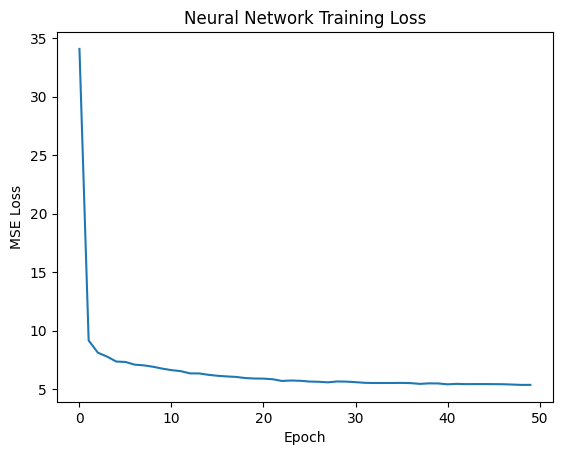

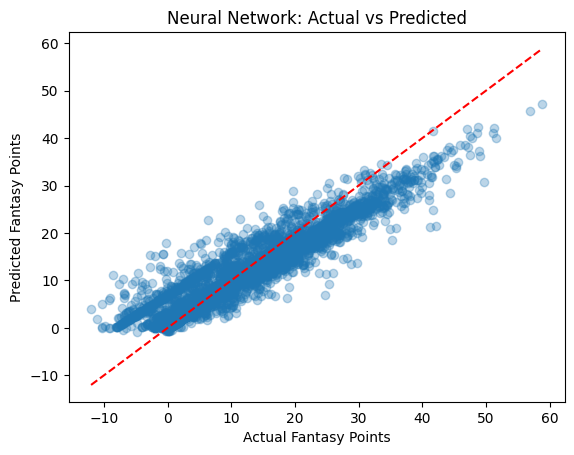

In [127]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split

# ── 1. Prep features (Model 3 top features) ──
features_nn = ['z_score_total_tds', 'avg_total_tds', 'avg_total_yards',
               'total_tds', 'td_pct', 'total_yards']

TARGET = 'fantasy_points_standard'

nn_data = player_weekly[features_nn + [TARGET]].dropna()
X_nn = nn_data[features_nn].values
y_nn = nn_data[TARGET].values

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y_nn, test_size=0.2, random_state=42
)

# Neural networks are sensitive to scale, so standardize
scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train_nn)
X_test_nn  = scaler.transform(X_test_nn)

# ── 2. Convert to tensors ──
X_train_t = torch.tensor(X_train_nn, dtype=torch.float32)
y_train_t = torch.tensor(y_train_nn, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test_nn,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test_nn,  dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)

# ── 3. Define the network ──
class FantasyNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_nn = FantasyNet(input_dim=len(features_nn)).to(device)

# ── 4. Train ──
optimizer = torch.optim.Adam(model_nn.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

EPOCHS = 50
train_losses = []

for epoch in range(EPOCHS):
    model_nn.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model_nn(X_batch)
        loss  = loss_fn(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {train_losses[-1]:.4f}")

# ── 5. Evaluate ──
model_nn.eval()
with torch.no_grad():
    train_preds = model_nn(X_train_t.to(device)).cpu().numpy()
    test_preds  = model_nn(X_test_t.to(device)).cpu().numpy()

train_r2   = r2_score(y_train_nn, train_preds)
test_r2    = r2_score(y_test_nn,  test_preds)
train_rmse = np.sqrt(mean_squared_error(y_train_nn, train_preds))
test_rmse  = np.sqrt(mean_squared_error(y_test_nn,  test_preds))

print("\nNeural Network (Model 3 Features)")
print(f"               {'Train':>10} {'Test':>10}")
print(f"  RMSE       : {train_rmse:>10.4f} {test_rmse:>10.4f}")
print(f"  R²         : {train_r2:>10.4f} {test_r2:>10.4f}")
print(f"  Overfit gap: {train_r2 - test_r2:>10.4f}")

# ── 6. Training loss curve ──
plt.plot(train_losses)
plt.title('Neural Network Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# ── 7. Actual vs Predicted ──
plt.scatter(y_test_nn, test_preds, alpha=0.3)
plt.xlabel('Actual Fantasy Points')
plt.ylabel('Predicted Fantasy Points')
plt.title('Neural Network: Actual vs Predicted')
plt.plot([y_test_nn.min(), y_test_nn.max()],
         [y_test_nn.min(), y_test_nn.max()], 'r--')
plt.show()

## Neural Network Results ##

Epoch 10/50 — Loss: 6.8374
Epoch 20/50 — Loss: 6.2167
Epoch 30/50 — Loss: 5.6900
Epoch 40/50 — Loss: 5.4786
Epoch 50/50 — Loss: 5.3780

Neural Network Metrics (Model 3 Features)
                           
  RMSE       :    Train 2.6082    Test  2.6212

  R²         :    Train 0.8899   Test  0.8888

  Overfit gap:     0.0011

KFOLD CV

In [130]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

X_cv = player_weekly[features_1].dropna()
y_cv = player_weekly.loc[X_cv.index, 'fantasy_points_standard']

existing_models = {
    "Ridge Regression": ridge_best,
    "Random Forest": random_forest,
    "Bagging": bagging_best,
    "Boosting": boost_best
}

cv_results = []

for name, existing_model in existing_models.items():
    scores = cross_validate(
        clone(existing_model),
        X_cv,
        y_cv,
        cv=kf,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    cv_results.append({
        "Model": name,
        "Train RMSE": round(-scores["train_rmse"].mean(), 4),
        "Test RMSE":  round(-scores["test_rmse"].mean(), 4),
        "RMSE Std":   round(scores["test_rmse"].std(), 4),
        "Test MAE":   round(-scores["test_mae"].mean(), 4),
        "Test R²":    round(scores["test_r2"].mean(), 4)
    })

baseline_preds_cv = np.full(len(y_cv), y_cv.mean())
cv_results.append({
    "Model": "Baseline (Mean)",
    "Train RMSE": None,
    "Test RMSE":  round(np.sqrt(mean_squared_error(y_cv, baseline_preds_cv)), 4),
    "RMSE Std":   None,
    "Test MAE":   None,
    "Test R²":    round(r2_score(y_cv, baseline_preds_cv), 4)
})

results_df = pd.DataFrame(cv_results).sort_values(by="Test RMSE")
print(results_df.to_string(index=False))

           Model  Train RMSE  Test RMSE  RMSE Std  Test MAE  Test R²
        Boosting      1.5673     1.6418    0.0251    0.6492   0.9564
   Random Forest      1.4370     1.6968    0.0353    0.6258   0.9534
Ridge Regression      1.7233     1.7249    0.0291    0.6961   0.9518
         Bagging      2.1400     2.1614    0.0547    1.0233   0.9244
 Baseline (Mean)         NaN     7.8597       NaN       NaN   0.0000
